In [13]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Directorios base
base_directories = {
    'Medellin_hd': r'F:\EEG_MULTICENTER\BIOMARCADORES',
    'Medellin_ld': r'F:\EEG_MULTICENTER\BIDS_PORTABLES_CODIFICADO',
    'Oslo': r'F:\EEG_MULTICENTER\SRM',
    'Dortmund': r'F:\EEG_MULTICENTER\Dortmund_Vital_Study',
    'Cuba': r'F:\EEG_MULTICENTER\CHMP',
    'Poland': r'F:\EEG_MULTICENTER\Polonia',
    'Chile': r'F:\EEG_MULTICENTER\BrainLat\CL_BIDS',
    'Argentina': r'F:\EEG_MULTICENTER\BrainLat\AR_BIDS',
    'Seoul': r'D:\MulticentersEEG\bids_cau_eyes_closed',
    'Greece': r'C:\Users\Luisa\Documents\DB_HARMONIZE\Grecia',
    'Spain': r'F:\EEG_MULTICENTER\BIDS_MUSCA_OO',
}


In [27]:
rejection_criteria = ['Kurtosis', 'Amplitude', 'Trend', 'Spectrum', 'Total']

def extract_rejection_data(site_name, base_path):
    rejection_data = []
    for pipeline in ['APPLEE', 'ALTERNATE_PIPELINE']:
        pipeline_path = os.path.join(base_path, 'derivatives', pipeline)
        if not os.path.exists(pipeline_path):
            continue
        for subject in os.listdir(pipeline_path):
            subject_path = os.path.join(pipeline_path, subject)
            if not os.path.isdir(subject_path):
                continue
            for root, _, files in os.walk(subject_path):
                for file in files:
                    if file.endswith('_stats.txt') and 'reject' in file:
                        try:
                            with open(os.path.join(root, file), 'r') as f:
                                data = json.load(f)
                            if 'final_rejection_percentages' in data:
                                values = data['final_rejection_percentages']
                                if len(values) == 5:
                                    rejection_data.append([site_name, pipeline, subject] + values)
                        except Exception:
                            continue
    return rejection_data

# Recolectar datos
all_data = []
for site, path in base_directories.items():
    all_data.extend(extract_rejection_data(site, path))

columns = ['SITE', 'PIPELINE', 'SUBJECT'] + rejection_criteria
df = pd.DataFrame(all_data, columns=columns)
for col in rejection_criteria:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.dropna(subset=rejection_criteria, inplace=True)

# Derretir y agrupar
df_melted = df.melt(id_vars=['SITE', 'PIPELINE'], value_vars=rejection_criteria,
                    var_name='Criterion', value_name='Rejection')
mean_df = df_melted.groupby(['Criterion', 'SITE', 'PIPELINE'])['Rejection'].mean().reset_index()



# Renombrar nombres de pipeline para la leyenda
mean_df['PIPELINE'] = mean_df['PIPELINE'].replace({
    'ALTERNATE_PIPELINE': 'P1',
    'APPLEE': 'P2'
})

# Multiplicar valores por 100 para representar porcentaje
mean_df['Rejection'] = mean_df['Rejection'] * 100


In [28]:
mean_df.groupby(['Criterion', 'PIPELINE'])['Rejection'].agg(['median', 'std']).reset_index()


,Criterion,PIPELINE,median,std
0,Amplitude,P1,9.196540,1.058631
1,Amplitude,P2,8.659539,1.272336
2,Kurtosis,P1,9.082635,0.530983
3,Kurtosis,P2,8.941533,0.685305
4,Spectrum,P1,6.585737,2.588575
5,Spectrum,P2,4.903304,2.607501
6,Total,P1,17.661411,2.135352
7,Total,P2,19.201563,2.134271
8,Trend,P1,0.000000,0.000658
9,Trend,P2,0.000000,0.000000


C:\Users\Luisa\AppData\Local\Temp\ipykernel_20464\3615638797.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_20464\3615638797.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_20464\3615638797.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_20464\3615638797.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

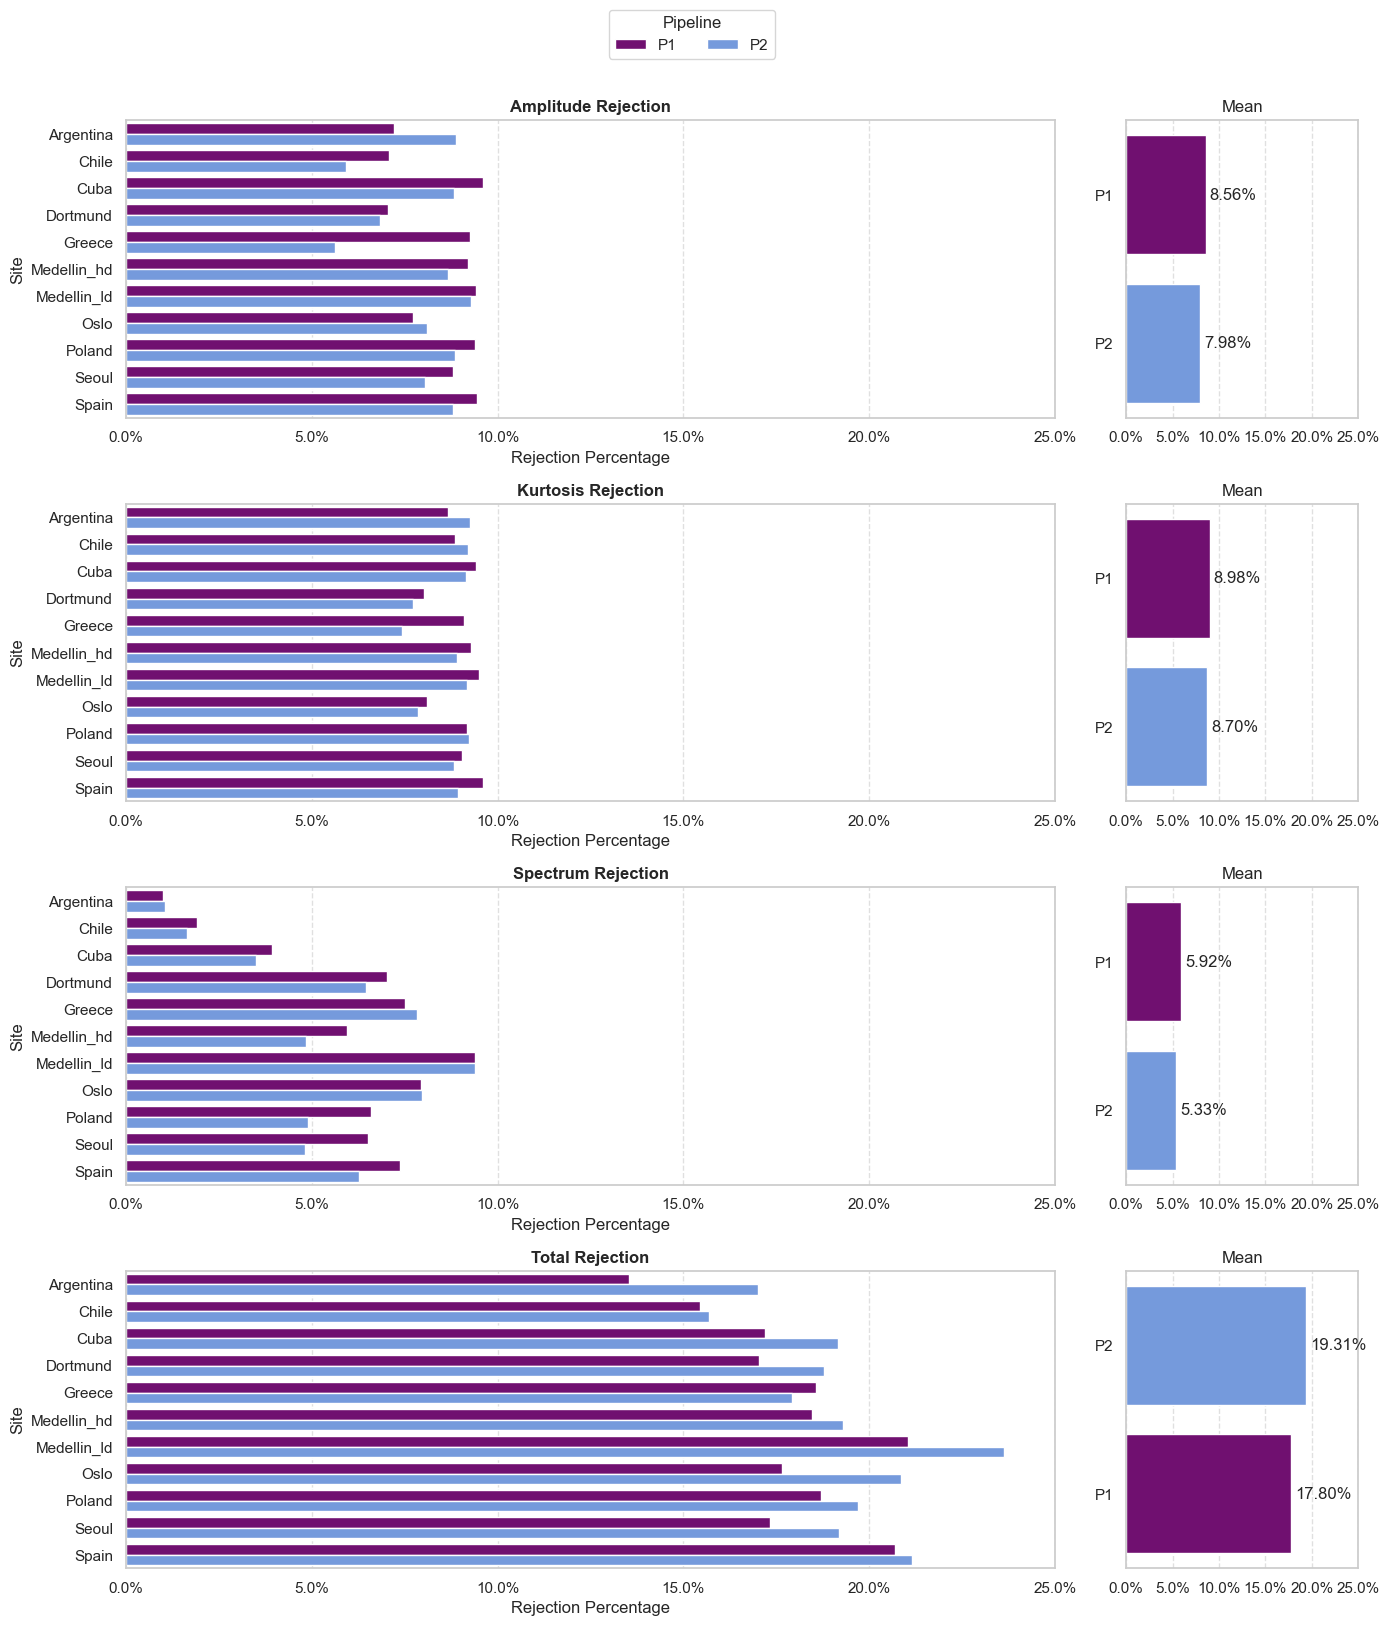

In [47]:
criteria = mean_df['Criterion'].unique()
n_criteria = len(criteria)
# Crear figura con 2 columnas: 1 para los subplots por criterio, 1 para el resumen
fig, axes = plt.subplots(n_criteria-1, 2, figsize=(14, n_criteria * 3.2), gridspec_kw={'width_ratios': [4, 1]})
palette = {'P2': 'cornflowerblue', 'P1': 'purple'}
for i, crit in enumerate(criteria[:-1]):
    subset = mean_df[mean_df['Criterion'] == crit]

    # Gráfico principal por site
    ax_main = axes[i, 0]
    sns.barplot(
        data=subset,
        x='Rejection',
        y='SITE',
        hue='PIPELINE',
        ax=ax_main,
        palette=palette
    )
    ax_main.set_title(f'{crit} Rejection', fontweight='bold')
    ax_main.set_ylabel('Site')
    ax_main.set_xlabel('Rejection Percentage')
    ax_main.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax_main.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=100))
    ax_main.set_xlim(0, 25)
    ax_main.grid(True, axis='x', linestyle='--', alpha=0.6)
    if ax_main.get_legend():
        ax_main.get_legend().remove()

    # Gráfico resumen (barra más pequeña a la derecha)
    ax_summary = axes[i, 1]
    means = (
        subset.groupby('PIPELINE')['Rejection']
        .mean()
        .reset_index()
        .sort_values('Rejection', ascending=False)
    )
    barplot = sns.barplot(
    data=means,
    x='Rejection',
    y='PIPELINE',
    palette=palette,
    ax=ax_summary
    )

    # Agregar etiquetas al final de las barras
    for container in barplot.containers:
        barplot.bar_label(container, fmt='%.2f%%', label_type='edge', padding=3)

    ax_summary.set_title('Mean')
    ax_summary.set_xlabel('')
    ax_summary.set_ylabel('')
    ax_summary.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=100))
    ax_summary.set_xlim(0, 25)
    ax_summary.grid(True, axis='x', linestyle='--', alpha=0.6)
    
   

# Leyenda general
handles, labels = ax_main.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, title='Pipeline')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\rejection_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()


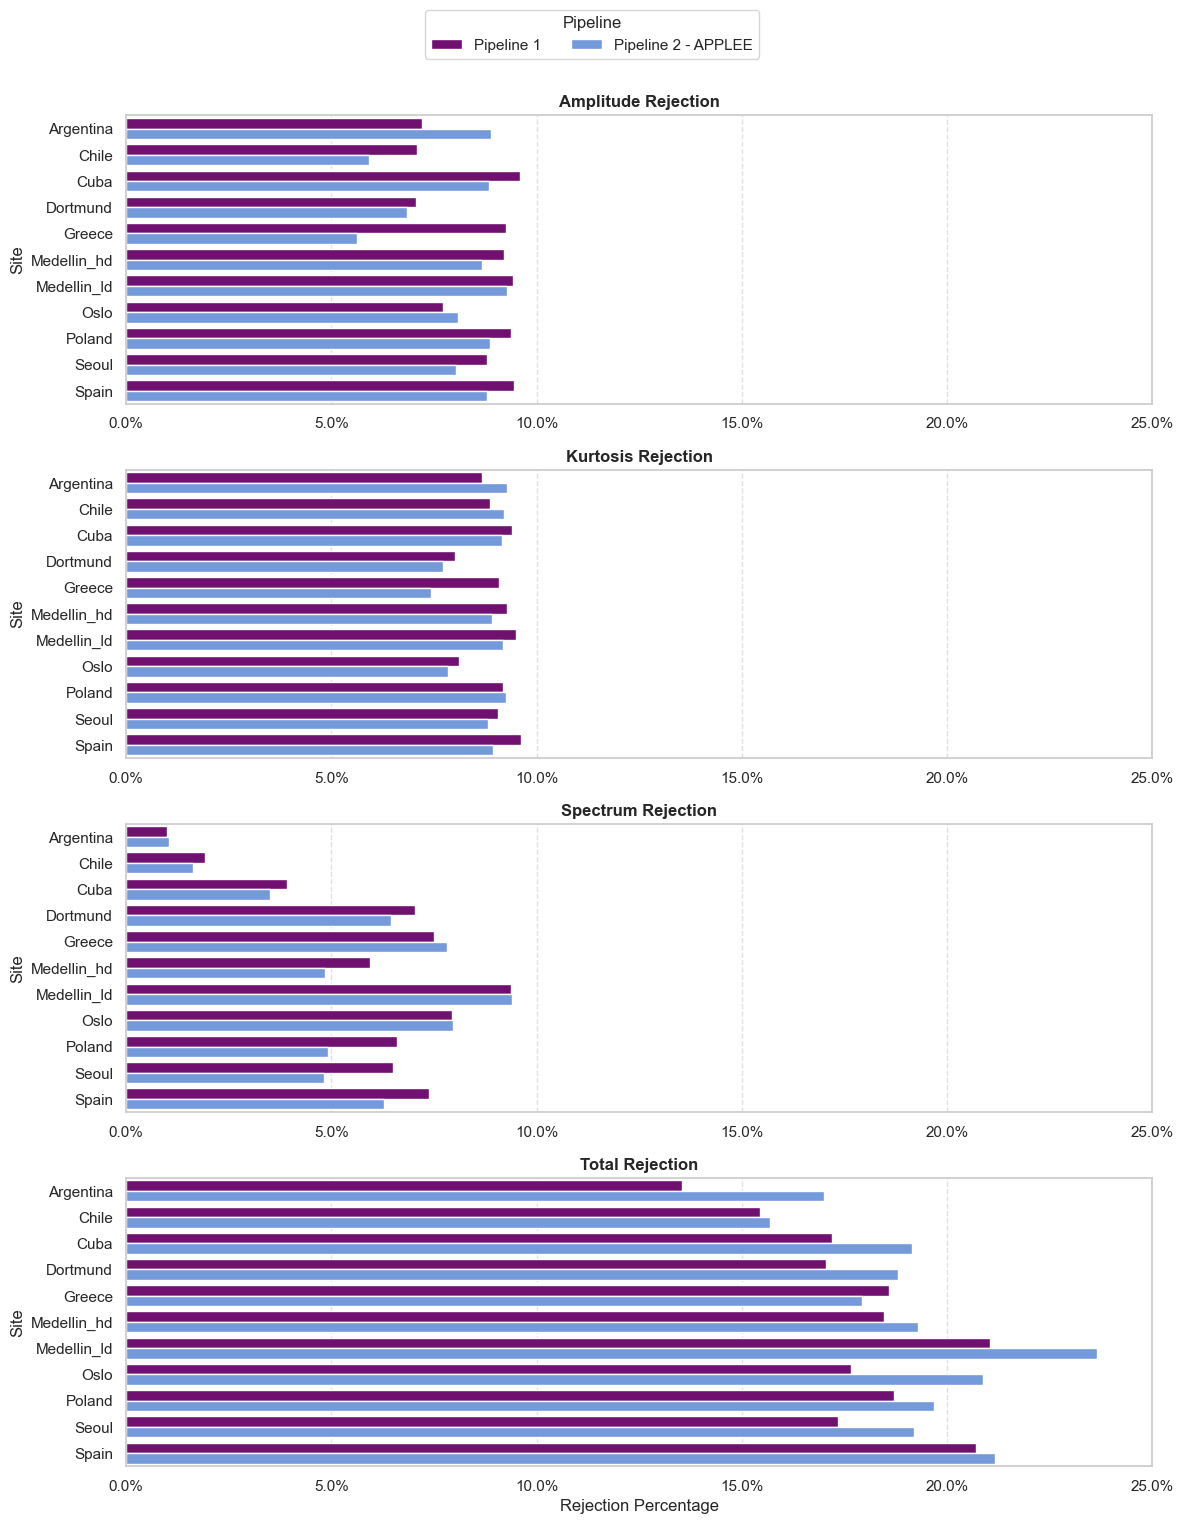

In [18]:
import matplotlib.ticker as ticker

# Plot
sns.set(style="whitegrid")
criteria = mean_df['Criterion'].unique()
n_criteria = len(criteria)

fig, axes = plt.subplots(n_criteria-1, 1, figsize=(12, n_criteria * 3), sharex=True)
palette = {'Pipeline 2 - APPLEE': 'cornflowerblue', 'Pipeline 1': 'purple'}

for i, crit in enumerate(criteria[:-1]):
    subset = mean_df[mean_df['Criterion'] == crit]
    ax = axes[i] if n_criteria > 1 else axes
    sns.barplot(
        data=subset,
        x='Rejection',
        y='SITE',
        hue='PIPELINE',
        ax=ax,
        palette=palette
    )
    ax.set_title(f'{crit} Rejection', fontweight='bold')
    ax.set_ylabel('Site')
    ax.set_xlabel('Rejection Percentage')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=100))
    ax.tick_params(axis='x', which='both', labelbottom=True)
    ax.set_xlim(0, 25) 

    ax.grid(True, axis='x', linestyle='--', alpha=0.6)
    if ax.get_legend():
        ax.get_legend().remove()
        
    

# Leyenda arriba
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, title='Pipeline')

plt.tight_layout(rect=[0, 0, 1, 0.97])  # deja espacio para la leyenda
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\rejection_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [28]:
import pandas as pd
path_criterials_remove = r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\report_IAF_by_sensor.xlsx"
data_hc = pd.read_excel(path_criterials_remove, sheet_name='Controls_report')

C:\Users\Luisa\AppData\Local\Temp\ipykernel_1340\2267341262.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_1340\2267341262.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_1340\2267341262.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_1340\2267341262.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` 

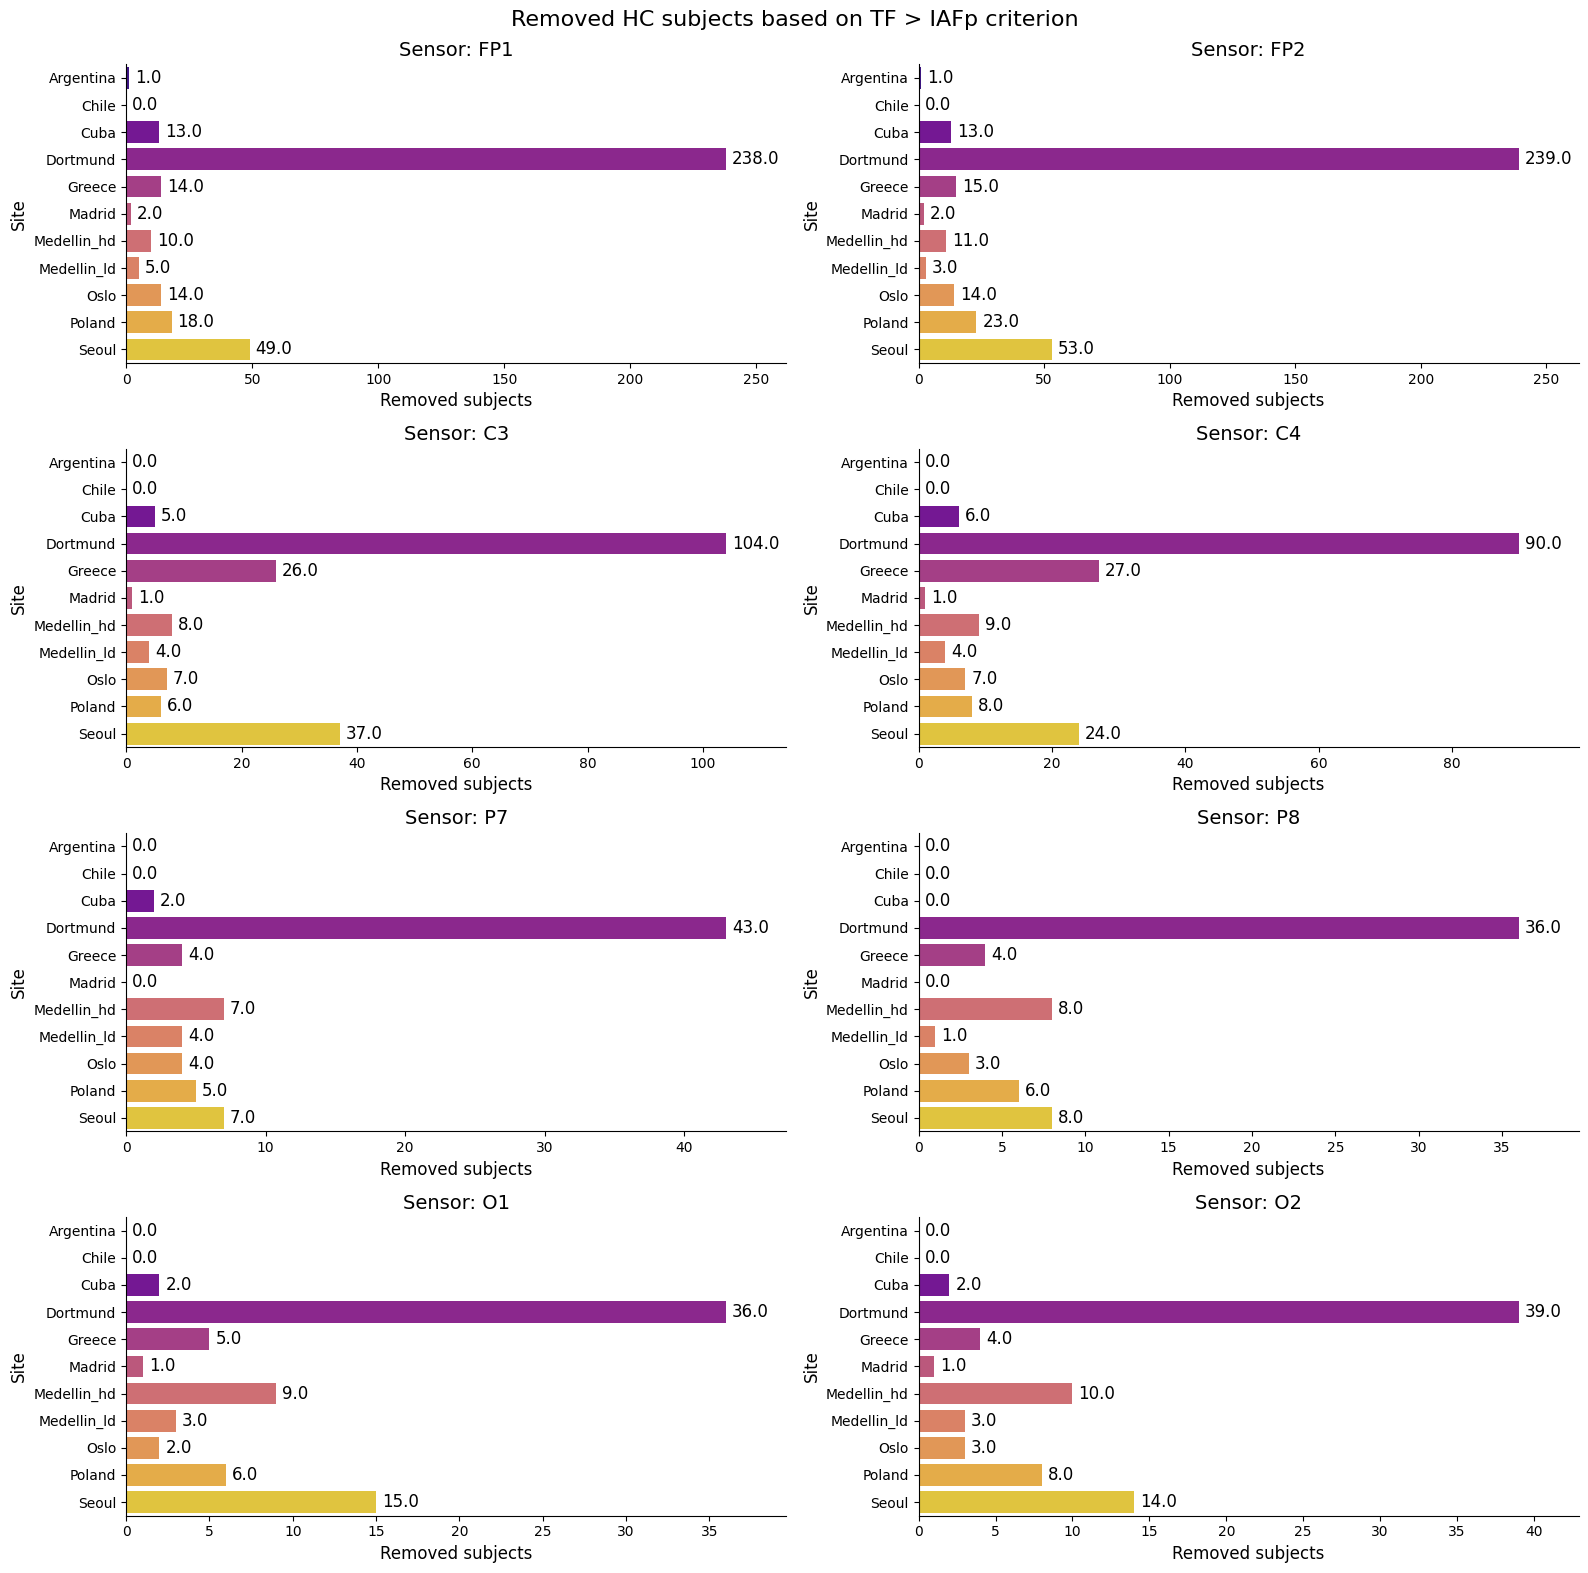

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Orden específico de sensores
sensors = ['FP1', 'FP2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))  # Aumenta el alto total
axes = axes.flatten()

for i, sensor in enumerate(sensors):
    ax = axes[i]
    data_sensor = data_hc[data_hc['Sensor'] == sensor]
    
    sns.barplot(
        data=data_sensor,
        x='TF > IAFp',
        y='SITE',
        ax=ax,
        palette='plasma'
    )

    ax.set_title(f'Sensor: {sensor}', fontsize=14)
    ax.set_ylabel('Site', fontsize=12)
    ax.set_xlabel('Removed subjects', fontsize=12)
    
    # Ajuste automático del límite X con un pequeño margen
    max_val = data_sensor['TF > IAFp'].max()
    ax.set_xlim(0, max_val * 1.1 if not pd.isna(max_val) else 1)
    
    # Añadir texto al final de cada barra
    for index, row in data_sensor.iterrows():
        ax.text(
            row['TF > IAFp'] + max_val * 0.01 if not pd.isna(max_val) else 0.1,
            row['SITE'],
            f"{row['TF > IAFp']:.1f}",
            va='center',
            fontsize=12
        )
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Ajustar primero los subplots, luego el título general
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.suptitle('Removed HC subjects based on TF > IAFp criterion', fontsize=16)

# Guardar y mostrar
fig.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\rejection_analysis_IAFp.pdf', dpi=300)
plt.show()


C:\Users\Luisa\AppData\Local\Temp\ipykernel_1340\3174506865.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_1340\3174506865.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_1340\3174506865.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_1340\3174506865.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` 

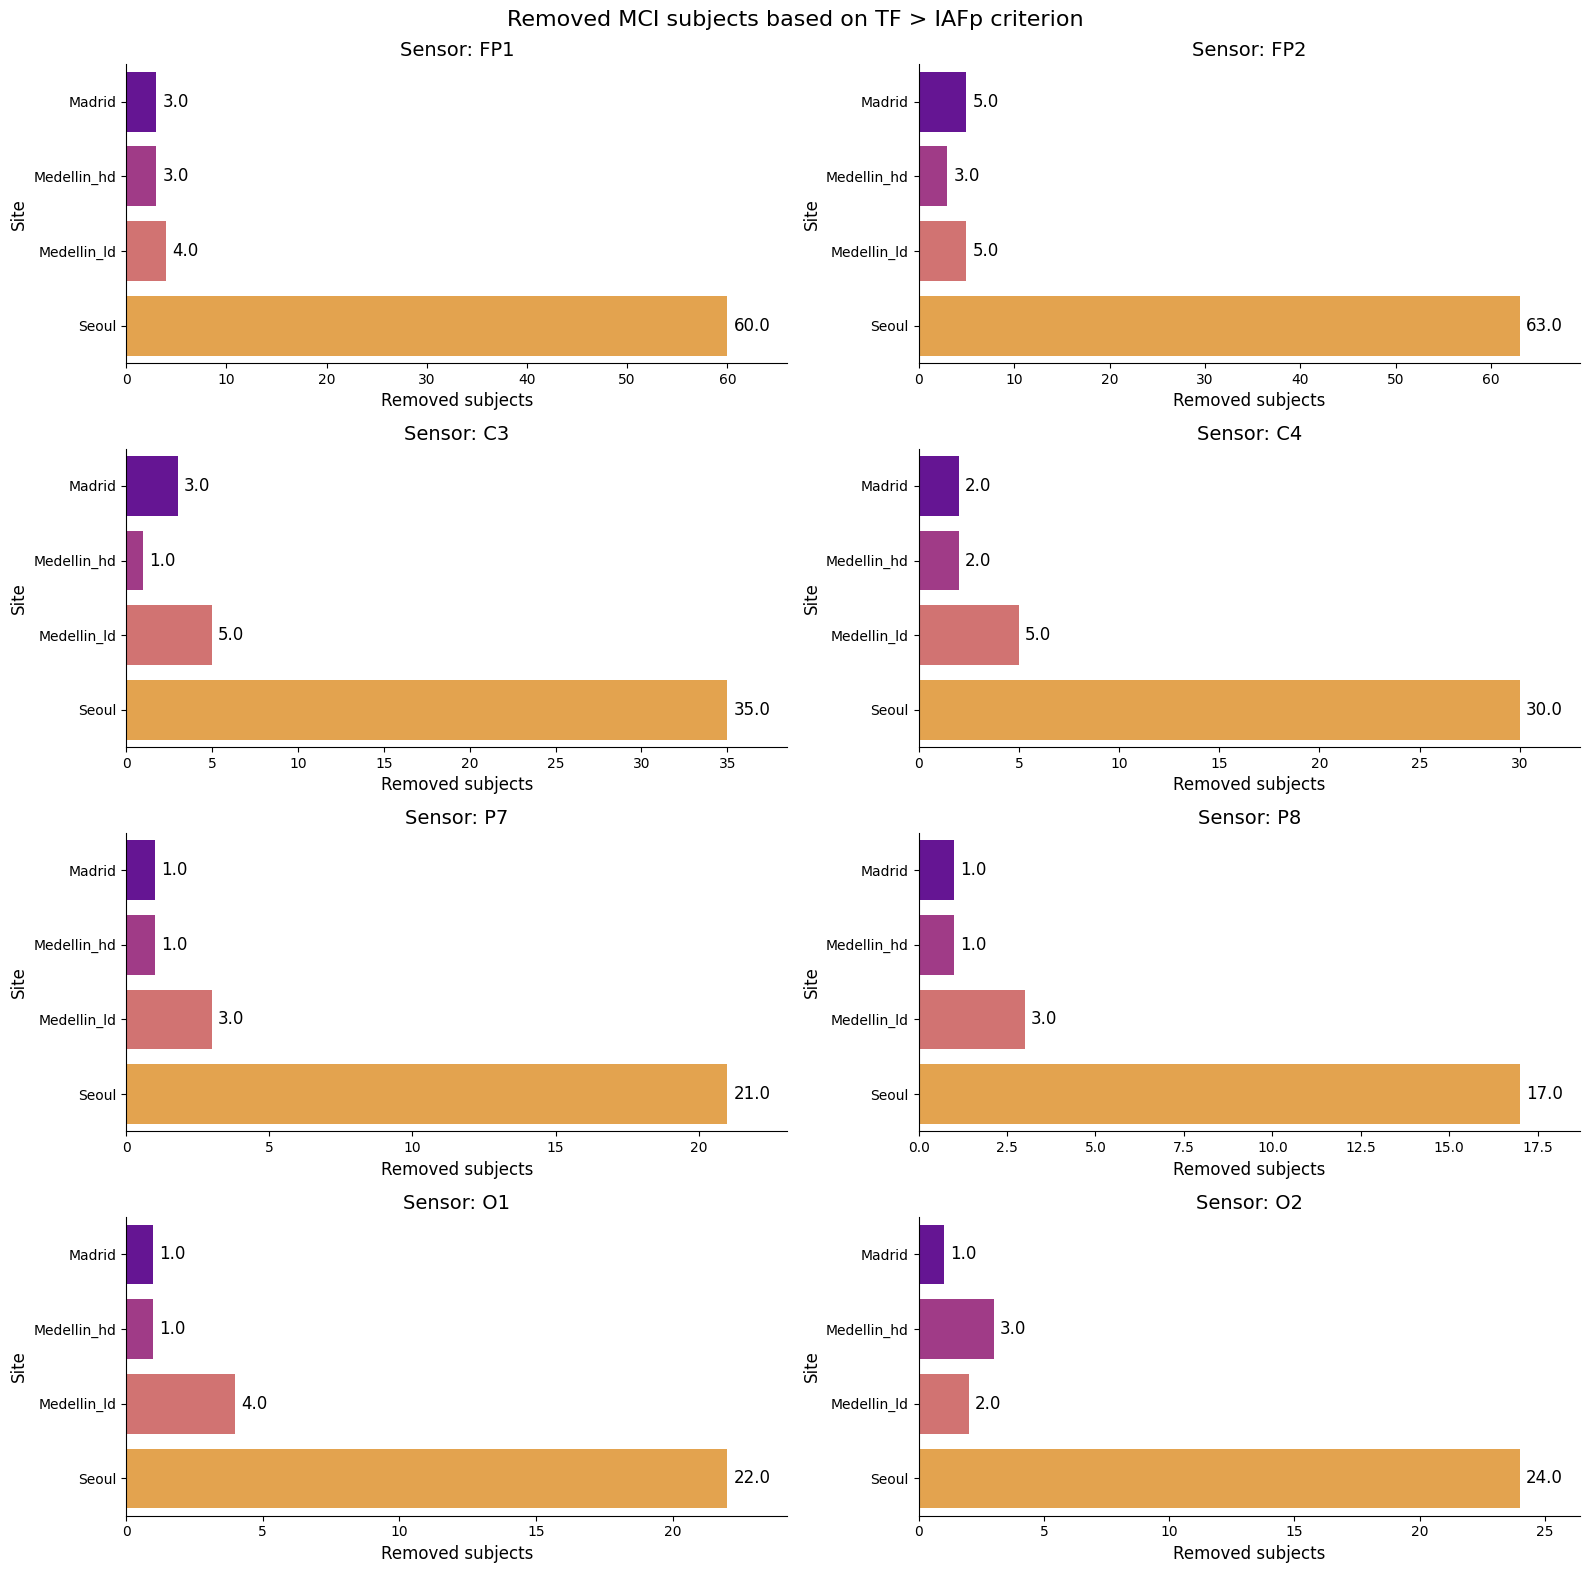

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  # Asegúrate de importar esto si no lo has hecho

data_mci = pd.read_excel(path_criterials_remove, sheet_name='MCI_report')

# Orden específico de sensores
sensors = ['FP1', 'FP2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))
axes = axes.flatten()

for i, sensor in enumerate(sensors):
    ax = axes[i]
    # Filtrar datos del sensor y eliminar filas con 0 o NaN en la columna 'TF > IAFp'
    data_sensor = data_mci[(data_mci['Sensor'] == sensor) & 
                           (data_mci['TF > IAFp'].fillna(0) > 0)]

    sns.barplot(
        data=data_sensor,
        x='TF > IAFp',
        y='SITE',
        ax=ax,
        palette='plasma'
    )

    ax.set_title(f'Sensor: {sensor}', fontsize=14)
    ax.set_ylabel('Site', fontsize=12)
    ax.set_xlabel('Removed subjects', fontsize=12)
    
    max_val = data_sensor['TF > IAFp'].max()
    ax.set_xlim(0, max_val * 1.1 if not pd.isna(max_val) else 1)
    
    for index, row in data_sensor.iterrows():
        ax.text(
            row['TF > IAFp'] + max_val * 0.01 if not pd.isna(max_val) else 0.1,
            row['SITE'],
            f"{row['TF > IAFp']:.1f}",
            va='center',
            fontsize=12
        )
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.suptitle('Removed MCI subjects based on TF > IAFp criterion', fontsize=16)

fig.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\rejection_analysis_IAFp_mci.pdf', dpi=300)
plt.show()


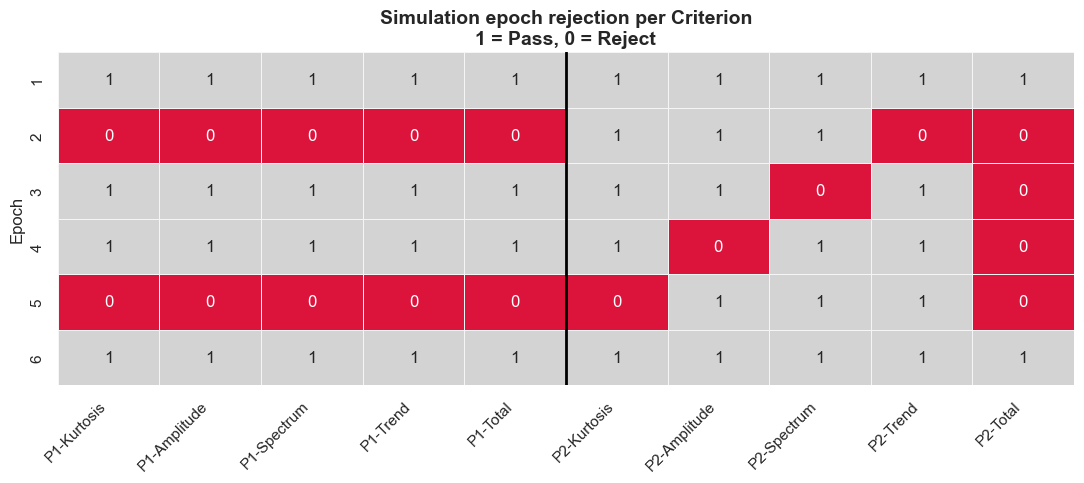

In [46]:
# Reimportar librerías tras el reset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

# Define criterios
criteria = ['Kurtosis', 'Amplitude', 'Spectrum', 'Trend']

# Simular datos para P1 (más estricto, pero errores concentrados)
pipeline1 = np.array([
    [1, 1, 1, 1],
    [0, 0, 0, 0],
    [1, 1, 1, 1],
    [1, 1, 1, 1],
    [0, 0, 0, 0],
    [1, 1, 1, 1]
])

# Simular datos para P2 (más laxo individualmente, pero errores dispersos)
pipeline2 = np.array([
    [1, 1, 1, 1],
    [1, 1, 1, 0],
    [1, 1, 0, 1],
    [1, 0, 1, 1],
    [0, 1, 1, 1],
    [1, 1, 1, 1]
])

# Función para añadir criterio total y convertir a DataFrame largo
def append_total_criterion(matrix, pipeline_label):
    total_col = np.prod(matrix, axis=1).reshape(-1, 1)
    matrix_with_total = np.hstack([matrix, total_col])
    criteria_extended = criteria + ['Total']
    df = pd.DataFrame(matrix_with_total, columns=criteria_extended)
    df['Epoch'] = np.arange(1, matrix.shape[0] + 1)
    df['Pipeline'] = pipeline_label
    return df.melt(id_vars=['Epoch', 'Pipeline'], var_name='Criterion', value_name='Pass')

# Convertir matrices a formato largo
df1 = append_total_criterion(pipeline1, 'P1')
df2 = append_total_criterion(pipeline2, 'P2')
df_all = pd.concat([df1, df2], ignore_index=True)

# Asegurar orden lógico de columnas
df_all['Criterion'] = pd.Categorical(df_all['Criterion'], categories=criteria + ['Total'], ordered=True)

# Colores personalizados
custom_cmap = ListedColormap(["crimson", "lightgrey"])

# Separación visual entre P1 y P2
n_criteria = len(criteria) + 1
separator_position = n_criteria

# Crear gráfico
plt.figure(figsize=(11, 5))
ax = sns.heatmap(
    df_all.pivot(index='Epoch', columns=['Pipeline', 'Criterion'], values='Pass'),
    cmap=custom_cmap,
    linewidths=0.5,
    linecolor='whitesmoke',
    cbar=False,
    annot=True
)

# Línea negra vertical separadora
ax.axvline(separator_position, color='black', linewidth=2)

# Ajustes de presentación
plt.title('Simulation epoch rejection per Criterion\n1 = Pass, 0 = Reject', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Epoch')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\rejection_analysis_simulation.pdf', dpi=300)
plt.show()
